In [1]:
import json
from pathlib import Path

#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
checkpoint_dir = Path("data") / "ch08_v4"

In [3]:
epoches, steps = [], []
train_losses, val_losses = [], []
learning_rates, created_at = [], []

json_files = sorted(
    checkpoint_dir.glob("*.json"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())

    tag = f.name.replace("checkpoint_", "").replace(".json", "")
    epoches.append(int(tag.split("-", 1)[0]))
    steps.append(int(tag.split("-", 1)[-1]))
    train_losses.append(data['train_loss'])
    val_losses.append(data['val_loss'])
    learning_rates.append(data['learning_rate'])
    created_at.append(data['created_at'])

In [4]:
df = pd.DataFrame({
    "epoch": epoches,
    "step": steps,
    "train_loss": train_losses,
    "val_loss": val_losses,
    "learning_rate": learning_rates,
    "created_at": created_at,
})


df = df.sort_values(by='step', ascending=True)

df.to_csv(checkpoint_dir / "training.tsv", index=False, sep='\t')

#print(df.nsmallest(1, 'train_loss'))
#pd.concat((df.head(10), df.tail(10)))
df

,epoch,step,train_loss,val_loss,learning_rate,created_at
0,1,8000,4.547843,4.547410,0.000038,2025-09-16T21:00:41%:z
1,1,16000,3.936555,4.011746,0.000076,2025-09-16T21:30:28%:z
2,1,24000,3.183966,3.367316,0.000114,2025-09-16T22:00:26%:z
3,1,32000,2.785131,3.029949,0.000152,2025-09-16T22:30:28%:z
4,1,40000,2.525321,2.844159,0.000191,2025-09-16T23:00:33%:z
5,1,48000,2.347004,2.724563,0.000229,2025-09-16T23:30:41%:z
6,1,56000,2.235862,2.662944,0.000267,2025-09-17T00:00:52%:z
7,1,64000,2.155473,2.617713,0.000300,2025-09-17T00:31:05%:z
8,1,72000,2.086599,2.582280,0.000300,2025-09-17T01:01:17%:z
9,1,80000,2.009095,2.553166,0.000299,2025-09-17T01:31:32%:z


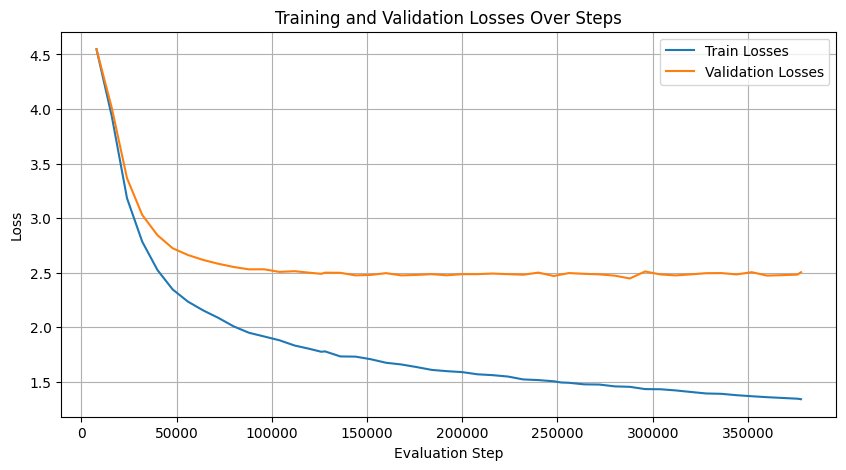

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(df['step'], df['train_loss'], label="Train Losses")
plt.plot(df['step'], df['val_loss'], label="Validation Losses")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
#plt.xlim(0, max(1e6, df["step"].max()))

plt.title("Training and Validation Losses Over Steps")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(checkpoint_dir / "training.pdf")

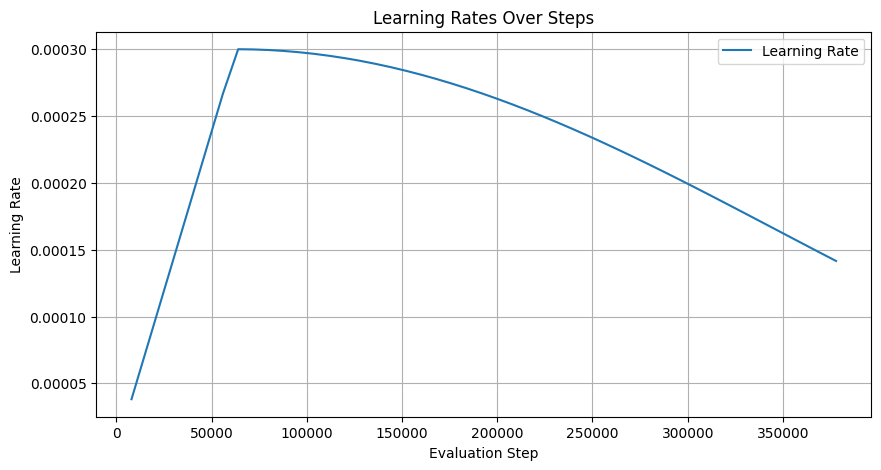

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(df['step'], df['learning_rate'], label="Learning Rate")
plt.xlabel("Evaluation Step")
plt.ylabel("Learning Rate")
plt.title("Learning Rates Over Steps")
plt.legend()
plt.grid()
#plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(checkpoint_dir / "learning_rate.pdf")